In [ ]:
%load_ext autoreload
%autoreload 2

from tensorboard.backend.event_processing import event_accumulator
import os
import scipy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm
import csv
from scipy.special import softmax
device = torch.device('cuda:0')
import random
import pickle
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(filename='train_log.log', level=logging.INFO)

from Dataset import *
from GAN import GAN, WGAN_GP
from Discriminator import DataDiscriminator, DeepSetCritic
from util import set_seed, jsd_from_samples
import itertools
import pandas as pd
#optimize over w directly, dont use any theta shenannigans. 
from sklearn import preprocessing
import pytorch_warmup as warmup
from DataProcessing import *
from attribution import *
from analysis import *

In [ ]:
#code for loading and  analyzing synth runs with top contributing vars
'''
1. Average gradient list over 100 runs compared to runs
2. Point system based on top 5 placement in gradients

3. (1-2) for points past 200
'''
import ast

def compute_sens_spec(STV_dict, RV_dict):
    '''
    STV_dict = point dict for Selected True Variables
    RV_dict = point dict for random variables

    specificty = TP / ( TP + FN )
    sensitivty = TN / (TN + FP)
    '''
    sens_num = 0
    sens_denom = 0
    spec_num = 0
    spec_denom = 0
    for k, v in STV_dict.items():
        sens_num += v[0]
        sens_denom += v[0]

        spec_denom += v[1] - v[0]
    
    for k, v in RV_dict.items():
        sens_denom += v[0]

        spec_num += v[1]
        spec_denom += v[1]

    print(sens_denom, spec_denom)
    return sens_num/sens_denom, spec_num / spec_denom

def compute_mean_grad(history,embedding_dict,
                      start_point=0,end_point=0):
    history = np.abs(history)
    all_grads = []
    summer = 0
    for k,v in embedding_dict.items():
        summer += v[2]

    for cgrad_idx in range(start_point,end_point):
        all_grads.append(process_grad(history[cgrad_idx],embedding_dict))

    lines = [[] for _ in range(len(all_grads[0]))]
    for g in all_grads:
        for var_idx in g:
            lines[var_idx].append(g[var_idx])
    
    lines = np.array(lines)
    return np.mean(lines,axis=1)

def normalize_x(values):
    normalized = [(x - min(values)) / (max(values) - min(values)) for x in values]
    return normalized

def calc_points(g_history, fname,
                embedding_dict, var_list, 
                points, rand_points, top_x,
                start, stop):
    mean_grads = compute_mean_grad(g_history,embedding_dict,
                                   start_point=start,
                                   end_point=stop)
    local_names_sorted, local_mean_grad_sorted = zip(*sorted(zip(copy.deepcopy(var_list), mean_grads), key=lambda x: x[1],reverse = True))
    for fname_k in fname:
        if fname_k in local_names_sorted[:top_x]:
            points[fname_k][0] += 1
        points[fname_k][1] += 1
    
    
    for i in range(1,8):
        rand_name = "rand_"+str(i)
        if rand_name in local_names_sorted[:top_x]:
            rand_points[rand_name][0] += 1
        else:
            rand_points[rand_name][1] += 1

def compute_means_rank(g_history, fname,
                embedding_dict, var_list, 
                points, rand_points, top_x,
                start, stop):

    ret_dict = {}
    mean_grads = compute_mean_grad(g_history,embedding_dict,
                                   start_point=start,
                                   end_point=stop)
    local_names_sorted, local_mean_grad_sorted = zip(*sorted(zip(copy.deepcopy(var_list), mean_grads), key=lambda x: x[1],reverse = True))
    #normalized = (local_mean_grad_sorted - np.min(local_mean_grad_sorted)) / (np.max(local_mean_grad_sorted) - np.min(local_mean_grad_sorted))

    return local_names_sorted, local_mean_grad_sorted

def create_rank_dict(all_names_sorted, all_means_sorted):
    ret_dict = {}
    for lns, lgs in zip(all_names_sorted, all_means_sorted):
        for i, ln in enumerate(lns):
            if ln not in ret_dict:
                ret_dict[ln] = [lgs[i]]
            else:
                ret_dict[ln].append(lgs[i])
    #mean of the means
    new_ret_dict = {}
    for k in ret_dict:
        new_ret_dict[k] = np.mean(ret_dict[k])
    mean_val = np.mean(list(new_ret_dict.values()))
    #then normalize
    final_ret_dict = {}
    for k in ret_dict:
        final_ret_dict[k] = new_ret_dict[k] / mean_val
    return final_ret_dict


def convert_point_dict_to_df(points,
                             col_names):
    sorted_v = []
    sorted_k = []
    sorted_tots = []
    for k, v in sorted(points.items(), key=lambda item: item[1][0], reverse = True):
        #print(k, v/(5*100))
        sorted_v.append(v[0])
        sorted_tots.append(v[1])
        sorted_k.append(k)
    df = pd.DataFrame([sorted_v,sorted_tots])
    df.columns = sorted_k
    df.index = col_names
    return df.T

#analyzing grad history}
file_path = "./saves_week29_2500_corrected_IG/"
all_files = os.listdir(file_path)

counter = 0
all_g_history = []
all_c_history = []
all_embedding_dicts = []
all_names = []
all_data = []

for fname in all_files:
    if "embedding" in fname or "runs" in fname:
        continue
    if "data" in fname:
        '''
        np.savez("./"+self.save_dir+"/data_"+str(trial_id)+".npz", x=self.unscaled_biased, 
                         y=self.biased_labels)
        '''
        test = np.load(file_path + "/" + fname)
        datum = test['x']
        labels = test['y']
        all_data.append({'data':datum,'label':labels})
    if "grad" in fname:
        suffix_isolated = fname.split("history")[1]
        suffix_isolated = suffix_isolated.split(".")[0]
        with open(file_path+"embedding_dict"+suffix_isolated+".pikl", 'rb') as file:
            embedding_dict = pickle.load(file)
        all_embedding_dicts.append(embedding_dict)
        #fname2 = "grad_history_0_['INCTOT', 'SEX'].npz"
        #if fname != "grad_history_0_['SEX', 'AGE'].npz":
        #    continue
        
        path = file_path+fname

        #syn parsing
        if False:
            fname_isolated = fname.split("_")[3]
            fname_isolated = fname_isolated.split(".")[0]
            fname_isolated = ast.literal_eval(fname_isolated)
        else:
            fname_isolated = fname.split("_")
            print(fname_isolated)
            fname_isolated = fname_isolated[2]

        fname_isolated = list(dict.fromkeys(s for tup in fname_isolated for s in tup))
        all_names.append(fname_isolated)
        
        loaded = np.load(path)

        all_g_history.append(loaded['w'])

        all_c_history.append(loaded['wc'])
    
    if False:
        top_x = 2
        if True:
            gen_points = calc_points(g_history,
                                    fname=fname_isolated,
                                    embedding_dict=embedding_dict,
                                    var_list=var_list,
                                    points=all_g_points,
                                    rand_points=all_g_rand,
                                    top_x = top_x,
                                    start=start_point,
                                    stop=stop_point)
        if True:
            critic_points = calc_points(c_history,
                                        fname=fname_isolated,
                                        embedding_dict=embedding_dict,
                                        var_list=var_list,
                                        points=all_c_points,
                                        rand_points=all_c_rand,
                                        top_x = top_x,
                                        start=start_point,
                                        stop=stop_point)
        
        gen_points_df = convert_point_dict_to_df(all_g_points,
                                                col_names=["Times in Top K", "Total Times Selected"])
        all_gen_rand_df = convert_point_dict_to_df(all_g_rand,
                                                col_names = ["Times in Top K", "times outside of top K"])
        critic_point_df = convert_point_dict_to_df(all_c_points,
                                                col_names = ["Times in Top K", "Total Times Selected"])
        all_critic_rand_df = convert_point_dict_to_df(all_c_rand,
                                                    col_names = ["Times in Top K", "times outside of top K"])
        if False:
            print(mean_grads.shape)
            var_list =  ['REGION', 'EDUC', 'INCTOT', 'SEX', 'MARST', 'RACE', 'AGE']
            for i in range(mean_grads.shape[1]):
                if i <= 6:
                    plt.scatter(np.arange(mean_grads.shape[0]),mean_grads[:,i], label=var_list[i])
            plt.legend()
            plt.ylim(0, 0.10)
            plt.title(path)
            plt.show()
        if False:
            all_grads = np.array(all_grads)
            averaged_experiment_grad = np.mean(all_grads,axis=0)
            averaged_experiment_grad = list(averaged_experiment_grad)
            names_sorted, mean_grad_sorted = zip(*sorted(zip(var_list, averaged_experiment_grad), key=lambda x: x[1],reverse = True))
            #mean_grad_sorted /= np.max(mean_grad_sorted)
            #mean_grad_sorted = normalize_x(mean_grad_sorted)
            mean_grad_sorted = mean_grad_sorted

In [ ]:
#specificty sensitivity analysis for synthetic random vars

for time_step in range(0,90,100):

    start_point = time_step
    stop_point = time_step+90
    if stop_point > all_g_history[0].shape[0]:
        stop_point = all_g_history[0].shape[0]

    all_g_points = {}
    all_c_points = {}
    all_g_rand = {}
    all_c_rand = {}

    var_list =  ['REGION', 'EDUC', 'INCTOT', 'SEX', 'MARST', 'RACE', 'AGE']
    #for i in range(7):
    #    var_list.append("rand_"+str(i+1))
    all_grads = []
    all_g_points = {}
    all_c_points = {}
    all_g_rand = {}
    all_c_rand = {}
    for v in var_list:
        if "rand" not in v:
            all_g_points[v] = [0,0]
            all_c_points[v] = [0,0]
        else:
            all_g_rand[v] = [0,0]
            all_c_rand[v] = [0,0]
    
    all_names_sorted = []
    all_means_sorted = []
    for i in range(len(all_g_history)):
        names_sorted, means_sorted = compute_means_rank(all_g_history[i],
                    fname=all_names[i],
                    embedding_dict=all_embedding_dicts[i],
                    var_list=var_list,
                    points=all_g_points,
                    rand_points=all_g_rand,
                    top_x = len(all_names[i]),
                    start=start_point,
                    stop=stop_point)
        all_names_sorted.append(names_sorted)
        all_means_sorted.append(means_sorted)
    
    print(len(all_names_sorted))
    if len(all_names_sorted) > 0:
        ret_dict = create_rank_dict(all_names_sorted,all_means_sorted)
        print(ret_dict)
    else:
        gen_points_df = convert_point_dict_to_df(all_g_points,
                                                col_names=["Times in Top K", "Total Times Selected"])
        all_gen_rand_df = convert_point_dict_to_df(all_g_rand,
                                                col_names = ["Times in Top K", "times outside of top K"])

        #print("Generator TV")
        #print(gen_points_df)
        #print("Generator Random")
        #print(all_gen_rand_df)

        gen_sens, gens_spec = compute_sens_spec(all_g_points, all_g_rand)
        print("Sensitivity/Specificty Analysis:")
        print("Generator: ", gen_sens, ",", gens_spec)
        print("")

for k, v in sorted(ret_dict.items(), key=lambda item: item[1]):
    print(k, v)

In [ ]:
#weight gradients computation. uses embedding dict
all_embedding_dicts

all_g_history[0].shape

'''
300 time steps
each time step 5 random points were selected
    where each point was from region 1 (likely different selected points at each time step)

each of the five points are the isolated gradient d W[i] / d X[i]
    first I found the entire jacobian dW[i] / d X, then simply selected the corresponding row.
    I stored them all in one matrix together, but these are isolated rows from unique jacobians (different i)

I discarded the rest of the jacobian because we only needed the gradient of the respective data point. 
'''

In [ ]:
#difference vector computations for synthetic
'''
the difference vectors are currently created manually, but the process can be automated

I create three difference vetors:
[-1, 1, 0, 0, ... 0] represents information flow from region 1 -> 2
[-1, 0, 1, 0, ... 0] represents information flow from region 1 -> 3
[-1, 0, 0, 1, ... 0] represents information flow from region 1 -> 4

I take the inner product of < d W[i] / d X[i], difference_vector> for i = 1...5
then average over all the inner products.

In terms of aggregating over time, I specify a window_size=100 (default) to see
how information flow changes over time during a single experiment. 
    This is accomplished by computing the averaged inner product, then averaging over a sliding non-overlapping window of 
    inner products. 

'''

def compute_averages_over_time(all_g_history, difference_vec):
    averaged_over_points = []
    for t in range(all_g_history[0].shape[0]):
        for i in range(all_g_history[0].shape[1]):
            out = 0
            out += np.inner(all_g_history[0][t,i,:],difference_vec)
        averaged_over_points.append(out/all_g_history[0].shape[1])

    window_size = 100
    average_over_time = [np.mean(averaged_over_points[i:i+window_size]) for i in range(0, len(averaged_over_points), window_size)]
    print("----------------------------------------")
    print("For diff vec: ", difference_vec[:4])
    print(average_over_time)

difference_vec = [-1, 1, 0, 0]
for _ in range(all_g_history[0].shape[2] - len(difference_vec)):
    difference_vec.append(0)
compute_averages_over_time(all_g_history, difference_vec)

difference_vec = [-1, 0, 1, 0]
for _ in range(all_g_history[0].shape[2] - len(difference_vec)):
    difference_vec.append(0)
compute_averages_over_time(all_g_history, difference_vec)

difference_vec = [-1, 0, 0, 1]
for _ in range(all_g_history[0].shape[2] - len(difference_vec)):
    difference_vec.append(0)
compute_averages_over_time(all_g_history, difference_vec)

In [ ]:
#difference vector computations for actual data
'''
1. create a "question", or at least a starting variable and value
2. isolate out the indexes from the data that match said question
3. compute average over all data points (no average over time as its just 1 time step)
'''
def create_var_dict():
    var_dict = {}
    for i,name in enumerate(['REGION', 'EDUC', 'INCTOT', 'SEX', 'MARST','RACE', 'AGE']):
        var_dict[i] = name
    print(var_dict)
    return var_dict

def randomly_select_valid_points(X,D,K):
    '''
    X - dataset - numpy array
    D - condition dictionary - dict[int] = str - key = var index, val = bucket index of var
    K - int - number of points to select
    '''
    # Start with a mask that selects all rows
    mask = np.ones(len(X), dtype=bool)

    if D is not None:
        # Apply each condition
        for feature_idx, category_id in D.items():
            mask &= (X[:, feature_idx] == category_id)

    # Filter rows
    matching_rows = np.where(mask)[0]

    if len(matching_rows) == 0:
        print("No matching rows found.")
        return np.empty((0, X.shape[1]))

    # Randomly sample up to K rows
    if K != np.inf:
        selected_indices = np.random.choice(matching_rows, size=min(K, len(matching_rows)), replace=False)
    else:
        selected_indices = matching_rows
    return selected_indices

def plot_all_heatmaps(mats, var_dict):
    all_labels = {
        0:['NE', 'S', 'MW', 'W'],
        1:['< HS', 'HS', '< BachDeg', 'BachDeg', 'GradDeg+'],
        2:['< 25k', '25k-35k', '35k-50k', '50k-75k', '75k-100k', '100k-150k', '150k-200k','200k+'],
        3:['M', 'F'],
        4:['Married', 'Widowed', 'Divorced', 'Separated', 'NeverMarried'],
        5:['White', 'Black', 'Asian', 'Other'],
        6:['18-34', '35-49','50-64','65-84','85+'],
    }

    fig, axes = plt.subplots(1, 7, figsize=(21, 3))

    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color='lightgray')  # neutral color for diagonal

    for i, (ax, mat) in enumerate(zip(axes, mats)):
        labels = all_labels[i]

        # Mask diagonal for min/max calculation
        masked_mat = np.ma.masked_array(mat, mask=np.eye(mat.shape[0], dtype=bool))
        local_min = masked_mat.min()
        local_max = masked_mat.max()

        max_abs = np.max(np.abs(mat))        # largest magnitude
        print(max_abs)
        norm_mat = mat / max_abs             # now values are between -1 and +1

        # Normalize matrix independently to [-1, 1]
        #norm_mat = 2 * (mat - local_min) / (local_max - local_min) - 1
        np.fill_diagonal(norm_mat, np.nan)  # make diagonal neutral

        # Plot
        im = ax.imshow(norm_mat, cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(var_dict[i])

        # Row/column ticks
        N = mat.shape[0]
        ax.set_xticks(np.arange(N))
        ax.set_xticklabels(labels)
        ax.xaxis.tick_top()
        ax.tick_params(axis='x', rotation=45)

        ax.set_yticks(np.arange(N))
        ax.set_yticklabels(labels)
        ax.yaxis.tick_left()

    # Optional: shared colorbar
    
    plt.tight_layout()
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.04)
    plt.show()
    
def create_all_grad_dicts(embedding_data):
    all_Ds = []
    all_Hs = []
    for q, v in embedding_data.items():
        for i in range(v[-1]):
            all_Ds.append({q:i})
        all_Hs.append(np.zeros((v[-1],v[-1])))
    return all_Ds, all_Hs

def create_all_difference_vectors(D, embed_dict):
    all_diff_vectors = []
    full_data_len = sum([ea[-1] for eq,ea in embed_dict.items()])
    for q,a in D.items():
        total_categories = embed_dict[q][-1]
        starting_index = sum([ea[-1]  for eq,ea in embed_dict.items() if eq < q])
        for i in range(total_categories):
            if i == a:
                all_diff_vectors.append(np.array([0 for _ in range(full_data_len)]))
            else:
                temp_dv = np.array([0 for _ in range(full_data_len)])
                temp_dv[starting_index + a] = -1
                temp_dv[starting_index + i] = 1
                all_diff_vectors.append(temp_dv)
    return all_diff_vectors

def compute_IG_averages_over_data(selected_grads, difference_vecs):
    all_dv_results = []
    for dv in difference_vecs:
        for i in range(selected_grads[0].shape[0]):
            out = 0
            out += np.inner(selected_grads[0][i,:],dv)
        all_dv_results.append(out/selected_grads[0].shape[1])
    return all_dv_results

#part 1 create question
embed_dict = all_embedding_dicts[0]
var_dict = create_var_dict()
X = all_data[0]['data']
all_Dicts, all_Heatmaps = create_all_grad_dicts(embed_dict)
embed_dict = all_embedding_dicts[0]
for D in all_Dicts:
    diff_vectors = create_all_difference_vectors(D, embed_dict)
    #part 2 isolate selected indices
    selected_indices = randomly_select_valid_points(X, D, K=np.inf)
    selected_X_grads = all_g_history[0][:,selected_indices,:]
    #part 3 compute average with diff vector
    all_dv_results = compute_IG_averages_over_data(selected_X_grads,diff_vectors)
    cur_Heatmap = all_Heatmaps[list(D.keys())[0]]
    for i, v in enumerate(all_dv_results):
        cur_Heatmap[list(D.values())[0],i] = all_dv_results[i]

        
print(all_Heatmaps[3])
#scale all heatmaps and plot
plot_all_heatmaps(all_Heatmaps, var_dict)

In [ ]:
#d4p processing continued 
from Dataset import D4P_dataset
EPOCHS = 100
DISC_LR = 1e-5
GT_LIMIT = 100 #25000
BIAS_LIMIT = 100 #1000
BATCH_SIZE =16
SUBSET_SIZE = 64
week='25'

seed=0
rngs = set_seed(seed,
                device,
                data_init=[True,True],
                data_gen =True,
                network_init=True,)

D1_rngs = copy.deepcopy(rngs)
D1_rngs['seed_bias'] = 359556
D2_rngs = copy.deepcopy(rngs)
D2_rngs['seed_bias'] = 280651
#load in both data sets

d = D4P_dataset(ground_truth_path='./data/censusHouseholdPulse_data/ipums_cleaned.csv',
            bias_path = './data/progress_data/week'+week+'_cleaned.csv',
            rngs=rngs,
            device=device,
            gt_limit = GT_LIMIT,
            )

In [ ]:
#analyzing the groupings of variables
#plotting events from saved run logs
# Path to the directory where SummaryWriter saved logs
import re
import ast
file_paths = ["runs_household_1_8_vars/"]

def isolate_variable_names(file_name):
    match = re.search(r"columns_to_keep:(\([^\)]*\))\|\|seed", file_name)
    if match:
        test = ast.literal_eval((match.group(1)))
        return test
    return None
def print_stats(runs_path):
    run_folders = []
    for name in os.listdir(runs_path):
        if os.path.isdir(os.path.join(runs_path,name)):
            run_folders.append(os.path.join(runs_path,name))

    event_files = []
    for run_folder in run_folders:
        for name in os.listdir(run_folder):
            if os.path.isdir(os.path.join(run_folder,name)):
                continue
            else:
                event_files.append(os.path.join(run_folder,name))

    all_vac_predictions = []
    all_l2_demographics = []
    all_names = []
    for i, event_file in enumerate(event_files):
        # Load event accumulator
        var_name_tuple = isolate_variable_names(event_file)
        if len(var_name_tuple) != num_vars:
            continue
        all_names.append(var_name_tuple)
        ea = event_accumulator.EventAccumulator(event_file)
        ea.Reload()
        #scalar_tags = ea.Tags().get('scalars', [])
        # List available tags (scalars, histograms, images, etc.)
        # Read scalar values (e.g., 'loss', 'accuracy')
        try:
            #demo_events = ea.Scalars("JS Divergence")
            demo_events = ea.Scalars("l2 norm demo diff")
            prediction_events = ea.Scalars("Vaccine prediction total") 
        except:
            print("error: ", event_file)
            continue
        #summ = 0
        #for iter, event in enumerate(prediction_events):
        #    print(event, l2_events[iter])
        cur_vac_pred = []
        cur_l2_demo = []
        for event in demo_events:
            cur_l2_demo.append(event.value)
        for event in prediction_events:
            cur_vac_pred.append(event.value)
        all_l2_demographics.append(cur_l2_demo)
        all_vac_predictions.append(cur_vac_pred)

    all_l2_demographics = np.array(all_l2_demographics)
    all_vac_predictions = np.array(all_vac_predictions)

    starting_prediction = []
    min_prediction = []
    for row in range(all_vac_predictions.shape[0]):
        starting_prediction.append(all_vac_predictions[row,0])
        min_prediction.append(np.min(all_vac_predictions[row,:]))

    combined = list(zip(all_names, starting_prediction, min_prediction))

    # Sort by the first element of each tuple (i.e., values from A)
    combined.sort(key=lambda x: x[2])

    # Unzip back into separate lists
    names_sorted, starting_sorted, min_sorted = zip(*combined)

    # Convert back to lists if needed
    names_sorted = list(names_sorted)
    starting_sorted = list(starting_sorted)
    min_sorted = list(min_sorted)
    
    results_dir = {}
    for ii, name_tup in enumerate(names_sorted):
        for nt in name_tup:
            if nt not in results_dir:
                results_dir[nt] = [min_sorted[ii]]
            else:
                results_dir[nt].append(min_sorted[ii])
    print("Mean min: ", np.mean(min_sorted))
    print("")
    print("Lower than mean:")
    for var in results_dir:
        if np.mean(results_dir[var]) < np.mean(min_sorted):
            print(var, np.mean(results_dir[var]))
    print("")

    print("Higher than mean:")
    for var in results_dir:
        if np.mean(results_dir[var]) > np.mean(min_sorted):
            print(var, np.mean(results_dir[var]))

    print("")

    x = 5
    for ii in range(x):
        print(names_sorted[ii], min_sorted[ii])

for runs_path in file_paths:
    print_stats(runs_path)

In [ ]:
#attempting to find trends in the randomness
#plotting events from saved run logs
# Path to the directory where SummaryWriter saved logs
file_paths = ["runs/"]
target_var_tb_name = "RECVDVACC prediction"
metric_tb_name = "tvd"
def print_stats(runs_path):
    run_folders = []
    for name in os.listdir(runs_path):
        if os.path.isdir(os.path.join(runs_path,name)):
            run_folders.append(os.path.join(runs_path,name))

    event_files = []
    for run_folder in run_folders:
        for name in os.listdir(run_folder):
            if os.path.isdir(os.path.join(run_folder,name)):
                continue
            else:
                event_files.append(os.path.join(run_folder,name))

    all_vac_predictions = []
    all_l2_demographics = []
    for i, event_file in enumerate(event_files):
        # Load event accumulator
        ea = event_accumulator.EventAccumulator(event_file)
        ea.Reload()

        # List available tags (scalars, histograms, images, etc.)
        # Read scalar values (e.g., 'loss', 'accuracy')
        prediction_events = ea.Scalars(target_var_tb_name)
        l2_events = ea.Scalars(metric_tb_name)
        #summ = 0
        #for iter, event in enumerate(prediction_events):
        #    print(event, l2_events[iter])
        cur_vac_pred = []
        cur_l2_demo = []
        for event in prediction_events:
            cur_vac_pred.append(event.value)
        for ievent in l2_events:
            cur_l2_demo.append(ievent.value)
        all_vac_predictions.append(cur_vac_pred)
        all_l2_demographics.append(cur_l2_demo)

    
    all_vac_predictions = np.array(all_vac_predictions)
    all_l2_demographics = np.array(all_l2_demographics)

    r_vales = []
    for i in range(1,70):
        start_point = 80
        end_point = np.shape(all_vac_predictions)[1]-i
        #ending points
        ending_vac_pred = all_vac_predictions[:,end_point]
        ending_l2_demopgrahics = all_l2_demographics[:,end_point]

        ending_vac_pred=np.delete(ending_vac_pred, ending_l2_demopgrahics.argmax())
        ending_l2_demopgrahics=np.delete(ending_l2_demopgrahics, ending_l2_demopgrahics.argmax())

        #plt.scatter(x=ending_l2_demopgrahics, y=ending_vac_pred)
        #plt.xlabel("Ending Demographic L2")
        #plt.ylabel("Ending Vac Prediction")
        #plt.show()
        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(ending_l2_demopgrahics, ending_vac_pred)
        r_vales.append(r_value)
        #print(r_value)
        #print("R value: ", r_value)
        #print("---------------------------------")
        #average from starting point
        #avg_vac_pred = np.mean(all_vac_predictions[:,start_point:],axis=1)
        #avg_l2_demo = np.mean(all_l2_demographics[:,start_point:],axis=1)
        #print(avg_vac_pred)
        #plt.scatter(x=avg_l2_demo, y=avg_vac_pred)
        #plt.xlabel("avg Demographic L2")
        #plt.ylabel("avg Vac Prediction")
        #slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(avg_vac_pred, avg_l2_demo)
        #print("R value: ", r_value)

    plt.plot(r_vales)

In [ ]:
# HHP Analysis Cell

runs_path = "runs_HHP_KLIEP_RESULTS_FINAL/"
target_var_tb_name = "RECVDVACC prediction"
metric_tb_name = "Gen Entropy"

for i in [ '0.0005']:
    indices = entropy_pred_relationship(runs_path,
                                    filter_by=["Week=29", "lambdaw:"+i], 
                                        num_runs=30,
                                        target_var_name=target_var_tb_name)

if False:
    indices = entropy_pred_relationship(runs_path,
                                    filter_by=["lambdaw:0.0025"], 
                                        num_runs=30,
                                        target_var_name=target_var_tb_name)

    indices = entropy_pred_relationship(runs_path,
                                    filter_by=["lambdaw:0.005"], 
                                        num_runs=30,
                                        target_var_name=target_var_tb_name)
#all_outs = HHP_load_all_weeks_as_dict('./runs/')

#process_all_weeks_dict(all_outs,
#                           "",
#                           save=False,)

In [ ]:
#Loading cell for EMPSTAT
from analysis import *
runs_path = 'runs/'
out, event_files = load_runs_as_numpy(runs_path,  
                             ['EMPSTAT prediction', 'GenLoss', 'Gen Entropy', 
                              'tvd', 'Warmup', 'Bias score', 'Gradient Penalty'],
                             filter_by=["factor:4"],
                             num_runs=30)

In [ ]:
#creating bias xbox and gt
GT_SIZE = 10000
BIAS_SIZE = 5000

test = XBoxDatasetSimulation("./data/gcHouse,7attributes.csv")
def save_new_XBOX_csvs():
    global_GT_dict, global_GT_var_order,global_bias_dict,global_bias_var_order = XBOX_get_GT_and_bias_ratios()

    GT_persons_count = get_all_persons_types_count(GT_SIZE,global_GT_dict)
    BT_persons_count = get_all_persons_types_count(BIAS_SIZE,global_bias_dict)

    GT_sampled_df = XBOX_get_sampled_df(global_GT_var_order,
                                        GT_persons_count,
                                        test.df)
    bias_sampled_df = XBOX_get_sampled_df(global_bias_var_order,
                                        BT_persons_count,
                                        test.df)

    bias_df_normalized, bias_NaN_columns = normalize_df(bias_sampled_df)
    gt_df_normalized, gt_df_NaN_columns = normalize_df(GT_sampled_df)
    all_NaNs_columns = bias_NaN_columns and gt_df_NaN_columns

    clean_NaN_by_col_index(bias_df_normalized,all_NaNs_columns)
    clean_NaN_by_col_index(gt_df_normalized,all_NaNs_columns)

    print(bias_df_normalized.shape, gt_df_normalized.shape)
    #save to CSV files
    bias_df_normalized = bias_df_normalized.sample(frac=1).reset_index(drop=True)
    gt_df_normalized = gt_df_normalized.sample(frac=1).reset_index(drop=True)

    bias_df_normalized.to_csv(BIAS_SAVE_PATH + "XBOX_bias.csv",index=False)
    gt_df_normalized.to_csv(GT_SAVE_PATH + "XBOX_GT.csv",index=False)

save_new_XBOX_csvs()

In [ ]:
#data analysis:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def analyze_dataset_differences(A, B, feature_names=None):
    """
    Analyzes differences between two datasets A and B.

    Args:
        A (np.ndarray): Dataset A, shape (N, D)
        B (np.ndarray): Dataset B, shape (M, D)
        feature_names (list[str], optional): List of feature names for plotting

    Returns:
        dict: Dictionary of comparison metrics per feature
    """
    assert A.shape[1] == B.shape[1], "Datasets must have the same number of features"
    D = A.shape[1]
    results = {}

    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(D)]

    for i in range(D):
        feat_A = A[:, i]
        feat_B = B[:, i]
        
        # Basic statistics
        mean_A, std_A = np.mean(feat_A), np.std(feat_A)
        mean_B, std_B = np.mean(feat_B), np.std(feat_B)
        
        # KS-test for distributional difference
        ks_stat, ks_pval = ks_2samp(feat_A, feat_B)

        results[feature_names[i]] = {
            "mean_A": mean_A,
            "mean_B": mean_B,
            "std_A": std_A,
            "std_B": std_B,
            "ks_stat": ks_stat,
            "ks_pval": ks_pval,
        }

        # Plot distributions
        plt.figure(figsize=(6, 4))
        sns.kdeplot(feat_A, label='Dataset A', fill=True)
        sns.kdeplot(feat_B, label='Dataset B', fill=True)
        plt.title(f"Distribution of {feature_names[i]}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results
GT_LIMIT = 25000
BIAS_LIMIT = 1000
seed=0
rngs = set_seed(seed,
                device,
                data_init=[True,True],
                data_gen =True,
                network_init=True,)
week='29'
D1_rngs = copy.deepcopy(rngs)
D1_rngs['seed_bias'] = 359556
D2_rngs = copy.deepcopy(rngs)
D2_rngs['seed_bias'] = 280651
#load in both data sets
D1 = HouseholdPulse_dataset(ground_truth_path='./data/censusHouseholdPulse_data/ipums_cleaned.csv',
                            bias_path = './data/censusHouseholdPulse_data/pulse_week'+week+'_cleaned.csv',
                            rngs=D1_rngs,
                            device=device,
                            gt_limit = GT_LIMIT,
                            bias_limit = BIAS_LIMIT, 
                            )
D2 = HouseholdPulse_dataset(ground_truth_path='./data/censusHouseholdPulse_data/ipums_cleaned.csv',
                            bias_path = './data/censusHouseholdPulse_data/pulse_week'+week+'_cleaned.csv',
                            rngs=D2_rngs,
                            device=device,
                            gt_limit = GT_LIMIT,
                            bias_limit = BIAS_LIMIT, 
                            )

analyze_dataset_differences(D1.unscaled_biased, D2.unscaled_biased, feature_names=None)

In [ ]:
#deepset classifier helper functions
def sample_dataset(dataset, batch_size, sample_size, rngs, weights=None):
    if weights is None:
        index = np.random.choice(np.arange(len(dataset)), size=sample_size*batch_size, p=weights)
    else:
        index = rngs['np'].choice(np.arange(len(dataset)),size=sample_size*batch_size)
    sampled_data = torch.clone(dataset[index])
    sampled_data = torch.reshape(sampled_data, (batch_size, sample_size, dataset.shape[1]))
    return sampled_data

def binary_accuracy_from_logits(logits, targets, threshold=0.5):
    preds = (logits > threshold).float()
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return 100.0 * correct / total


In [ ]:
#making new household census data

from HouseholdCensusDataProcessing import * 
census_df = None
survey_df = None

for w in range(29,30):
    print("processing: ", w)
    week = str(w)
    #week="ALL"
    census_df = pd.read_csv("./data/HouseholdPulse_data/raw_census/usa_00008.csv")
    #survey_df = pd.read_csv("./data/HouseholdPulse_data/raw_survey/pulse2021_puf_"+week+".csv")
    survey_df, census_df, census_df_combined = recoding_survey_and_census_data(survey_df, census_df, target_var=['RECVDVACC']) #HLTHINS1 or RECVDVACC
    #survey_df = load_evenly_sampled_csv_rows("./data/HouseholdPulse_data/raw_survey/", 2500, "HLTHINS1")
    #survey_df.to_csv('./data/HouseholdPulse_data/cleaned/pulse_week'+week+'_cleaned.csv', index=False)
    #census_df_combined.to_csv('./data/HouseholdPulse_data/cleaned/ipums_cleaned_combined.csv',index=False)

In [ ]:
import math
df = census_df
cols = ['REGION','EDUC','INCTOT','SEX','MARST','RACE','AGE']
category_counts = {
    'REGION': 4,
    'EDUC':   5,
    'INCTOT': 8,
    'SEX':    2,
    'MARST':  5,
    'RACE':   4,
    'AGE':    5
}

# 1) total possible combinations
total_possible = math.prod(category_counts[c] for c in cols)
print("Total possible combinations:", total_possible)  # -> 32000

# 2) observed unique combinations in dataframe df
observed_unique_tuples = set(tuple(row) for row in df[cols].drop_duplicates().itertuples(index=False, name=None))
observed_unique = len(observed_unique_tuples)
print("Observed unique combinations:", observed_unique)

# 3) how many missing
missing_count = total_possible - observed_unique
print("Missing combinations:", missing_count)
print("Fraction missing: {:.2%}".format(missing_count / total_possible))

# 4) build all possible combos and list missing ones
ranges = [range(category_counts[c]) for c in cols]
all_combos = set(itertools.product(*ranges))

missing_combos = all_combos - observed_unique_tuples
# convert to DataFrame for easy inspection
missing_df = pd.DataFrame(list(missing_combos), columns=cols)
print("Example missing combos (first 10):")
print(missing_df.head(10))
# if you want the entire missing_df sorted:
missing_df = missing_df.sort_values(cols).reset_index(drop=True)

In [ ]:
#Making new D4p Data
from D4PDataProcessing import *
census_df = None
survey_df = None
import numpy as np

for w in range(25,26):
    #print("processing: ", w)
    week = str(w)
    #week="ALL"
    census_df = pd.read_csv("./data/HouseholdPulse_data/raw_census/usa_00008.csv")
    #survey_df = pd.read_csv("./data/progress_data/raw_survey/raw_week_"+week+".csv")
    survey_df, census_df, census_df_combined = recoding_survey_and_census_data(survey_df, census_df, target_var=['RECVDVACC', 'HLTHINS1']) #HLTHINS1 or RECVDVACC
    #survey_df = load_evenly_sampled_csv_rows("./data/progress_data/raw_survey/", 2500, "HLTHINS1")
    #survey_df.to_csv('./data/progress_data/cleaned/pulse_week'+week+'_cleaned.csv', index=False)
    census_df_combined.to_csv('./data/progress_data/cleaned/ipums_cleaned_combined.csv',index=False)

if False:
    def encode_employment(value):   
        try:
            value = str(value)
            if 'no' in value.lower():
                return 0
            if 'yes' in value.lower():
                return 1
        except (ValueError, TypeError):
            return None
    survey_df = survey_df.filter(items=['vax', 'nationalweight'])
    survey_df['vax'] = survey_df['vax'].apply(encode_employment)
    survey_df = survey_df.dropna()
    a = survey_df['nationalweight'].to_numpy()
    a /= np.sum(a)
    b = survey_df['vax'].to_numpy()
    print(w, np.sum(a * b))


In [ ]:
#making new household census data with CPS census

from CPSDataProcessing import * 
census_df = None
survey_df = None

for w in range(8,9):
    print("processing: ", w)
    week = str(w)
    #week="ALL"
    #census_df = pd.read_csv("./data/censusHouseholdPulse_data/raw_census/cps_00005.csv")
    survey_df = pd.read_csv("./data/censusHouseholdPulse_data/raw_survey/pulse2024_puf_"+week+".csv")
    survey_df, census_df = CPS_recoding_survey_and_census_data(survey_df, census_df, target_var=['EMPSTAT']) #empstat
    #survey_df = load_evenly_sampled_csv_rows("./data/censusHouseholdPulse_data/raw_survey/", 2500, "HLTHINS1")
    survey_df.to_csv('./data/censusHouseholdPulse_data/cleaned/pulse_week'+week+'_cleaned.csv', index=False)
    #census_df.to_csv('./data/censusHouseholdPulse_data/cleaned/cps_cleaned.csv',index=False)


In [ ]:
#making new axios ipsos data
from AxiosIpsosDataProcessing import * 
import os
census_df = None
survey_df = None

survey_path = "./data/axios_ipsos_data/raw_survey/"
survey_files = os.listdir("./data/axios_ipsos_data/raw_survey/")

for w in survey_files:
    print("processing: ", w)
    week = w.split("_")[0]
    #week="ALL"
    #census_df = pd.read_csv("./data/censusHouseholdPulse_data/raw_census/usa_00008.csv")
    survey_df = pd.read_csv(os.path.join(survey_path,w), encoding='ISO-8859-1')
    #survey_df, census_df = axios_recoding_survey_and_census_data(survey_df, census_df, target_var=['RECVDVACC']) #empstat
    #survey_df.to_csv('./data/axios_ipsos_data/cleaned/week'+week+'_cleaned.csv', index=False)
    #census_df.to_csv('./data/axios_ipsos_data/cleaned/ipums_cleaned.csv',index=False)

    if False: #prints out weighted vaccine predictions
        vaccine_mapping = {
                'Yes, I have received the vaccine': 1,
                'Skipped': 0
        }
        survey_df['Q107_1'] = survey_df['Q107_1'].map(vaccine_mapping)
        weight_name = 'wt_final'
        if weight_name in survey_df:
            a = survey_df['wt_final'].to_numpy()
        else:
            a = survey_df['wt_final_pid'].to_numpy()
        a /= np.sum(a)
        b = survey_df['Q107_1'].to_numpy()
        print(w)
        print(np.sum(a * b))
        print("")

In [ ]:
#compare dataframes
def compare_dataframes(df1, df2):
    assert list(df1.columns) == list(df2.columns), "Columns must match"

    cols = df1.columns
    n_cols = len(cols)
    n_rows = (n_cols + 2) // 3  # auto-layout: 3 columns per row

    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        ax.boxplot([df1[col].dropna(), df2[col].dropna()], labels=["Survey", "Census"])
        ax.set_title(f"Column: {col}")
        ax.grid(True)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

compare_dataframes(survey_df.iloc[:, 1:],census_df.iloc[:,1:])

In [ ]:
def sample_categorical_distribution(df, column, target_dist, K, replace=False, random_state=None):
    """
    Sample K rows from df such that the distribution of the values in the specified column
    matches the target categorical distribution.

    Parameters:
        df (pd.DataFrame): Original DataFrame.
        column_index (int): Index of the column to match distribution on.
        target_dist (dict): Target distribution (e.g., {0: 0.5, 1: 0.3, 2: 0.2}).
        K (int): Total number of samples to draw.
        replace (bool): Whether to sample with replacement.
        random_state (int or None): Seed for reproducibility.

    Returns:
        pd.DataFrame: Sampled DataFrame of size K.
    """
    np.random.seed(random_state)
    result_dfs = []
    
    for category, proportion in target_dist.items():
        num_samples = int(round(proportion * K))
        subset = df[df[column] == category]
        
        if len(subset) == 0:
            raise ValueError(f"No samples found for category '{category}' in the specified column.")
        if not replace and num_samples > len(subset):
            raise ValueError(f"Not enough samples in category '{category}' to sample {num_samples} without replacement.")
        
        sampled = subset.sample(n=num_samples, replace=replace, random_state=random_state)
        result_dfs.append(sampled)
    
    result = pd.concat(result_dfs).sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # Fix any rounding issues (e.g., if total != K due to rounding)
    if len(result) > K:
        result = result.sample(n=K, random_state=random_state)
    elif len(result) < K:
        extra = df.sample(n=K - len(result), replace=replace, random_state=random_state)
        result = pd.concat([result, extra]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return result

def solo_var_experiment(ground_truth_path,
                        target_column,
                        target_dist,
                        gt_size,
                        bias_size,):
    raw_gt_load = pd.read_csv(ground_truth_path)

    biased_dataset = sample_categorical_distribution(raw_gt_load, target_column, target_dist, bias_size, replace=False, random_state=None).to_numpy(dtype=np.float, na_value=0)
    gt_dataset = raw_gt_load.sample(n=gt_size).to_numpy(dtype=np.float, na_value=0)
    

ground_truth_path='./data/censusHouseholdPulse_data/ipums_cleaned.csv'

In [ ]:
#making new ari data set
from AriSurveyDataProcessing import * 
census_df = None
survey_df = None

#census_df = pd.read_csv("./data/ari_survey/raw_census/CPSData_823_Lucid.csv")
survey_df = pd.read_csv("./data/ari_survey/raw_survey/aug23data.csv")
survey_df, census_df = recoding_survey_and_census_data(survey_df, census_df,target_var=['EMPSTAT'])
survey_df.to_csv('./data/ari_survey/cleaned/ari_cleaned.csv', index=False)
#census_df.to_csv('./data/ari_survey/cleaned/cps_cleaned.csv',index=False)

In [ ]:
#Nearest neighbor with weights analysis
from scipy.spatial import cKDTree
from attribution import compute_confusion_matrix_NN
from util import plot_heatmaps

folder = "./saves_week29_NN_exp/"
data_name = "data_0.npz"
weights_name = "weights_0_.npz"
embed_name = "embedding_dict_0_.pikl"

data = np.load(folder + data_name)
x = data['x']
y = data['y']
weights = np.load(folder+weights_name)['w'].flatten()
with open(folder + embed_name, 'rb') as file:
    embed_dict = pickle.load(file)

all_conf_matrices = compute_confusion_matrix_NN(dataset=x,
                            labels=y,
                            weights=weights,
                            embed_dict=embed_dict,)


      
all_labels = {
        0:['NE', 'S', 'MW', 'W'],
        1:['< HS', 'HS', '< BachDeg', 'BachDeg', 'GradDeg+'],
        2:['< 25k', '25k-35k', '35k-50k', '50k-75k', '75k-100k', '100k-150k', '150k-200k','200k+'],
        3:['M', 'F'],
        4:['Married', 'Widowed', 'Divorced', 'Separated', 'NeverMarried'],
        5:['White', 'Black', 'Asian', 'Other'],
        6:['18-34', '35-49','50-64','65-84','85+'],
    }
var_list =  ['REGION', 'EDUC', 'INCTOT', 'SEX', 'MARST', 'RACE', 'AGE']

plot_heatmaps(all_conf_matrices, all_labels,titles=var_list)

In [ ]:
#Logit difference computation in attribution.py plotting below.

from util import plot_heatmaps, plot_heatmaps_multiplicative
all_labels = {
        0:['NE', 'S', 'MW', 'W'],
        1:['< HS', 'HS', '< BachDeg', 'BachDeg', 'GradDeg+'],
        2:['< 25k', '25k-35k', '35k-50k', '50k-75k', '75k-100k', '100k-150k', '150k-200k','200k+'],
        3:['M', 'F'],
        4:['Married', 'Widowed', 'Divorced', 'Separated', 'NeverMarried'],
        5:['White', 'Black', 'Asian', 'Other'],
        6:['18-34', '35-49','50-64','65-84','85+'],
    }
var_list =  ['REGION', 'EDUC', 'INCTOT', 'SEX', 'MARST', 'RACE', 'AGE']
folder = "./saves_week29/"
with open(folder+"/temp_conf_weighted_matrix.pikl", 'rb') as file:
    all_conf_matrices = pickle.load(file)
plot_heatmaps(all_conf_matrices, all_labels,titles=var_list)
plot_heatmaps_multiplicative(all_conf_matrices, all_labels,titles=var_list)

In [ ]:
#testing weight quality visualization
folder = "./saves_week29/"
data_name = "data_0.npz"
weights_name = "weights_0_.npz"
embed_name = "embedding_dict_0_.pikl"
data = np.load(folder + data_name)
x = torch.tensor(data['x']).long()
y = data['y']
weights = torch.tensor(np.load(folder+weights_name)['w'].flatten())
with open(folder + embed_name, 'rb') as file:
    embed_dict = pickle.load(file)
ground_truth_path='./data/HouseholdPulse_data/cleaned/ipums_cleaned.csv'
df = pd.read_csv(ground_truth_path)
raw_gt_load = torch.tensor(df.to_numpy(dtype=float, na_value=0)[:,1:]).long()
print(x.dtype, weights.dtype)
print(x.shape)

In [ ]:
#auto tuning code, still need to refine
%autoreload 2
from stability import *

smoothing_cfg = SmoothingConfig(ema_alpha=0.01)

plateau_cfg = PlateauSearchConfig(
    window_frac=0.40,
    min_window_points=12,
    range_pct=0.15,                  # loosened: allow a bit more tail movement
    slope_pct=0.10,                  # loosened: allow small ongoing drift in plateau
    plateau_start_frac_default=0.30, # "generally later 60%" => plateau can start after 40%
    overall_change_tol_pct=0.02,     # TVD non-increasing tolerance
)

trend_cfg = TrendConfig(
    overall_min_change_pct=0.06      # loosened net-change requirement
)

bias_cfg = BiasTrendConfig(
    tail_frac=0.50,
    tail_rise_min_pct=0.01,        # loosen if needed
    tail_max_downstep_frac=0.35,   # allow some wiggle
)

def total_score(results_dict):
    """
    results_dict: Dict[str, MetricResult]
    """
    return sum(r.points for r in results_dict.values())


def sort_and_print_runs(run_results):
    """
    run_results: List[Tuple[str, Dict[str, MetricResult]]]
                 [(filename, results_dict), ...]
    """

    # Sort by total score (descending)
    sorted_runs = sorted(
        run_results,
        key=lambda x: total_score(x[1]),
        reverse=True
    )

    print("\n=== Runs sorted by score (high → low) ===")
    for filename, results in sorted_runs:
        score = total_score(results)
        print(f"{score:>3}  |  {filename}")

folder_path = "./runs/"

all_results = []
for file in os.listdir(folder_path):
    if "VAR = lambdaw:0.05||seed:918808" not in file:
        continue
    if "iter: 0" not in file:
        continue
    if "Week=25" not in file:
        continue

    full_file_path = os.path.join(folder_path, file)    
    #print(file)
    results = analyze_and_score(
        file_path=full_file_path,
        smoothing=smoothing_cfg,
        plateau_cfg=plateau_cfg,
        trend_cfg=trend_cfg,
        bias_cfg=bias_cfg,
        plot=True,
    )
    summarize_results(results)
    all_results.append([file,results])

sort_and_print_runs(all_results)


In [ ]:
#2 way z test between source and target
import numpy as np
from math import erf, sqrt


# -----------------------------
# Normal helpers (no scipy)
# -----------------------------
def _normal_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def _two_sided_p_from_z(z: float) -> float:
    return 2.0 * (1.0 - _normal_cdf(abs(z)))


# -----------------------------
# One-sample proportion test
# (A vs benchmark B proportion)
# -----------------------------
def _one_sample_prop_ztest(xA: int, nA: int, pB: float):
    """
    H0: pA == pB, where pB is treated as fixed "true" benchmark.
    Returns (z, p_value).
    """
    if nA <= 0:
        return np.nan, np.nan

    pB = float(min(1.0, max(0.0, pB)))
    pA = xA / nA
    diff = pA - pB

    var = pB * (1.0 - pB) / nA

    if var == 0.0:
        # If pB is 0 or 1, only exact equality yields p=1
        if abs(diff) < 1e-15:
            return 0.0, 1.0
        return np.inf, 0.0

    z = diff / sqrt(var)
    pval = _two_sided_p_from_z(z)
    return z, pval


# -----------------------------
# Main table builder
# -----------------------------
def compare_A_to_weighted_B_table(
    A: np.ndarray,
    B: np.ndarray,
    B_w: np.ndarray,
    *,
    col_names=None,
    missing_value: int = -1,
    include_missing: bool = False,
    normalize_Bw: bool = True,
):
    """
    Builds a row-per-(variable, level) table comparing:
      - A: individual-level sample (unweighted)
      - B: aggregated rows with true proportions B_w (treated as benchmark)

    For each (j,k):
      A_n, A_pct
      B_pct (from weighted sum)
      diff = A_pct - B_pct
      direction (over/under)
      z, p_value  (one-sample proportion z-test)

    Returns: list[dict]
    """
    A = np.asarray(A)
    B = np.asarray(B)
    B_w = np.asarray(B_w, dtype=float)
    print(A.shape, B.shape)
    if A.ndim != 2 or B.ndim != 2:
        raise ValueError("A and B must be 2D arrays.")
    if A.shape[1] != B.shape[1]:
        raise ValueError("A and B must have same number of columns.")
    if B_w.ndim != 1 or B_w.shape[0] != B.shape[0]:
        raise ValueError("B_w must be 1D and align with rows of B.")

    nA_total, p = A.shape

    if normalize_Bw:
        s = B_w.sum()
        if not np.isfinite(s) or s <= 0:
            raise ValueError("B_w must sum to a positive finite number.")
        if abs(s - 1.0) > 1e-10:
            B_w = B_w / s
    print("AAA: ", p)
    if col_names is None:
        col_names = [f"Var{j}" for j in range(p)]
    if len(col_names) != p:
        raise ValueError("col_names length must equal number of variables (cols).")

    rows = []

    for j in range(p):
        Aj = A[:, j].astype(int)
        Bj = B[:, j].astype(int)

        if include_missing:
            maskA = np.ones(Aj.shape[0], dtype=bool)
            maskB = np.ones(Bj.shape[0], dtype=bool)
        else:
            maskA = (Aj != missing_value)
            maskB = (Bj != missing_value)

        Ajv = Aj[maskA]
        nA = Ajv.size

        Bjv = Bj[maskB]
        Bwv = B_w[maskB]

        if Ajv.size == 0 and Bjv.size == 0:
            continue

        # union of observed levels (in A or B), excluding missing if requested
        levels = np.unique(np.concatenate([Ajv, Bjv])) if Bjv.size else np.unique(Ajv)

        # Efficient counts/weights by level using bincount (0-based integers)
        max_lvl = int(levels.max()) if levels.size else -1

        a_counts = np.bincount(Ajv, minlength=max_lvl + 1) if nA > 0 and max_lvl >= 0 else np.zeros(max_lvl + 1, dtype=int)
        b_props = np.bincount(Bjv, weights=Bwv, minlength=max_lvl + 1) if Bjv.size > 0 and max_lvl >= 0 else np.zeros(max_lvl + 1, dtype=float)

        for k in levels:
            k = int(k)

            xA = int(a_counts[k]) if k < a_counts.shape[0] else int(np.sum(Ajv == k))
            pA = (xA / nA) if nA > 0 else np.nan

            pB = float(b_props[k]) if k < b_props.shape[0] else float(np.sum(B_w[(B[:, j] == k)]))

            z, pval = _one_sample_prop_ztest(xA, nA, pB)

            diff = (pA - pB) if np.isfinite(pA) else np.nan

            if not np.isfinite(diff):
                direction = ""
            elif diff > 0:
                direction = "A > B"
            elif diff < 0:
                direction = "A < B"
            else:
                direction = "A = B"

            rows.append({
                "Var": j,
                "VarName": col_names[j],
                "Level": k,
                "A_n": xA,
                "A_%": pA * 100.0 if np.isfinite(pA) else np.nan,
                "B_%": pB * 100.0,
                "Diff(pp)": diff * 100.0 if np.isfinite(diff) else np.nan,  # percentage points
                "Direction": direction,
                "z": z,
                "p_value": pval,
                "A_N": int(nA),
            })

    return rows


def print_table_by_variable(rows, *, decimals=3, gap_lines=3):
    if not rows:
        print("(no rows)")
        return

    def fmt(v):
        if v is None:
            return ""
        if isinstance(v, float):
            if np.isnan(v):
                return ""
            if np.isinf(v):
                return "inf"
            return f"{v:.{decimals}f}"
        return str(v)

    # helper: first 4 letters, padded with spaces
    def short_varname(name: str) -> str:
        name = str(name)
        return (name[:4]).ljust(4)

    # group rows by variable index
    by_var = {}
    for r in rows:
        by_var.setdefault(r["Var"], []).append(r)

    for _, var_rows in by_var.items():
        var_name = short_varname(var_rows[0]["VarName"])

        print(f"Variable: {var_name}")
        print()

        header = ["Lvl", "A n", "A %", "B %", "Diff(pp)", "Dir", "p-value"]

        table = []
        for r in var_rows:
            table.append([
                r["Level"],
                r["A_n"],
                r["A_%"],
                r["B_%"],
                r["Diff(pp)"],
                r["Direction"],
                r["p_value"],
            ])

        cols = list(zip(*([header] + table)))
        widths = [max(len(fmt(x)) for x in col) for col in cols]

        def render(row):
            return " | ".join(fmt(x).ljust(w) for x, w in zip(row, widths))

        print(render(header))
        print("-+-".join("-" * w for w in widths))
        for row in table:
            print(render(row))

        # space between variables
        print("\n" * gap_lines, end="")



# -----------------------------
# Example
# -----------------------------
if __name__ == "__main__":
    if False:
        A = np.array([
            [0, 1, 2],
            [1, 0, 2],
            [0, 1, 1],
            [2, 0, 2],
        ], dtype=int)

        B = np.array([
            [0, 1, 2],
            [0, 0, 2],
            [1, 0, 1],
            [2, 1, 2],
        ], dtype=int)
    week='29'
    ground_truth_path='./data/HouseholdPulse_data/cleaned/ipums_cleaned_combined.csv'
    bias_path = './data/HouseholdPulse_data/cleaned/pulse_week'+week+'_cleaned.csv'
    raw_bias_load = pd.read_csv(bias_path)
    col_names = raw_bias_load.columns.to_list()[1:]
    raw_bias_load = raw_bias_load.to_numpy()
    raw_gt_load = pd.read_csv(ground_truth_path).to_numpy(na_value=0)
    rows = compare_A_to_weighted_B_table(raw_bias_load[:,1:], 
                                         raw_gt_load[:,1:],  
                                         raw_gt_load[:,0], 
                                         col_names=col_names)
    print_table_by_variable(rows, decimals=3)


In [58]:
import os
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
from scipy.ndimage import uniform_filter1d


def analyze_tensorboard_files(directory_path, filter_string, tag_string, smoothing_window=10, 
                               plateau_threshold=0.01, min_plateau_length=5):
    """
    Analyzes TensorBoard files to find plateau points and compute averages.
    
    Handles nested directory structure: Main folder -> Save folder -> event file
    Filters by checking if filter_string appears in the save folder name or file.
    
    If no plateau is detected, prints a warning and returns average of maximum values.
    
    Parameters:
    -----------
    directory_path : str
        Path to main directory containing subdirectories with TensorBoard event files
    filter_string : str
        String to filter by folder/file names (checks save folder names and filenames)
    smoothing_window : int, default=10
        Window size for moving average smoothing
    plateau_threshold : float, default=0.01
        Threshold for detecting plateau (max allowed change rate)
    min_plateau_length : int, default=5
        Minimum number of consecutive points to confirm plateau
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'plateau_detected': Boolean indicating if any plateaus were found
        - 'avg_plateau_index': Average index where plateau starts (None if no plateau)
        - 'avg_plateau_value': Average of post-plateau values (None if no plateau)
        - 'avg_max_value': Average of maximum values across all files
        - 'individual_plateau_indices': List of plateau indices (None for files without plateau)
        - 'individual_plateau_values': List of avg post-plateau values (None for files without plateau)
        - 'individual_max_values': List of maximum values for each file
        - 'file_names': List of processed file names (format: "folder_name/event_file")
        - 'plateau_detected_count': Number of files where plateau was detected
        - 'total_files': Total number of files processed
    """
    
    def smooth_data(values, window_size):
        """Apply moving average smoothing."""
        if len(values) < window_size:
            window_size = max(1, len(values) // 2)
        return uniform_filter1d(values, size=window_size, mode='nearest')
    
    def detect_plateau(smoothed_values, threshold, min_length):
        """
        Detect where the curve plateaus.
        Returns the index where plateau begins, or None if no plateau detected.
        """
        if len(smoothed_values) < min_length + 1:
            return None
        
        # Calculate the rate of change
        differences = np.abs(np.diff(smoothed_values))
        
        # Normalize by the value to get relative change
        with np.errstate(divide='ignore', invalid='ignore'):
            relative_changes = differences / (np.abs(smoothed_values[:-1]) + 1e-10)
        
        # Find where consecutive points have low relative change
        plateau_candidates = relative_changes < threshold
        
        # Look for sustained plateau (min_length consecutive True values)
        for i in range(len(plateau_candidates) - min_length + 1):
            if np.all(plateau_candidates[i:i + min_length]):
                return i
        
        # No clear plateau found
        return None
    
    # Find all TensorBoard event files
    # Directory structure: Main folder -> Additional Save folder with name -> event file
    tb_files = []
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            # Check if the file is a TensorBoard event file
            if 'events.out.tfevents' in file or 'tfevents' in file:
                # Check if the filter_string is in the parent directory name or file path
                parent_dir = os.path.basename(os.path.dirname(root))
                immediate_parent = os.path.basename(root)
                
                if (filter_string in immediate_parent or 
                    filter_string in parent_dir or 
                    filter_string in file):
                    tb_files.append(os.path.join(root, file))
    
    if not tb_files:
        raise ValueError(f"No TensorBoard files found with filter string '{filter_string}' in {directory_path}")
    
    plateau_indices = []
    plateau_values = []
    min_values = []
    file_names = []
    plateau_detected_count = 0
    
    for tb_file in tb_files:
        try:
            # Load TensorBoard file
            ea = event_accumulator.EventAccumulator(tb_file)
            ea.Reload()
            
            # Get available scalar tags
            scalar_tags = ea.Tags()['scalars']
            
            # Find the "Truth - Fake scores" tag
            target_tag = None
            for tag in scalar_tags:
                if tag_string in tag:
                    target_tag = tag
                    break
            
            if target_tag is None:
                print(f"Warning: " + tag_string + " not found in {tb_file}, skipping...")
                continue
            
            # Load the scalar data
            scalar_events = ea.Scalars(target_tag)
            values = np.array([event.value for event in scalar_events])
            
            if len(values) == 0:
                print(f"Warning: No data in {tb_file}, skipping...")
                continue
            
            # Smooth the data
            smoothed_values = values #smooth_data(values, smoothing_window)
            
            # Store maximum value
            min_value = np.min(smoothed_values)
            min_values.append(min_value)
            
            # Detect plateau
            print(len(smoothed_values))
            plateau_idx = len(smoothed_values)//2 #detect_plateau(smoothed_values, plateau_threshold, min_plateau_length)
            
            # Include the parent folder name for identification
            folder_name = os.path.basename(os.path.dirname(tb_file))
            file_names.append(f"{folder_name}/{os.path.basename(tb_file)}")
            
            # Store results based on whether plateau was detected
            if plateau_idx is not None:
                # Calculate average of post-plateau values
                post_plateau_values = smoothed_values[plateau_idx:]
                avg_post_plateau = np.mean(post_plateau_values)
                
                plateau_indices.append(plateau_idx)
                plateau_values.append(avg_post_plateau)
                plateau_detected_count += 1
            else:
                # No plateau detected for this file
                plateau_indices.append(None)
                plateau_values.append(None)
            
        except Exception as e:
            print(f"Error processing {tb_file}: {str(e)}")
            continue
    
    if not file_names:
        raise ValueError("No valid data was extracted from any TensorBoard files")
    
    # Check if plateaus were detected
    if plateau_detected_count == 0:
        # No plateaus detected in any file
        print("\n" + "="*60)
        print("NO PLATEAU DETECTED in any of the analyzed files!")
        print("="*60)
        avg_min_value = np.mean(min_values)
        
        return {
            'plateau_detected': False,
            'avg_plateau_index': None,
            'avg_plateau_value': None,
            'avg_max_value': avg_min_value,
            'individual_plateau_indices': plateau_indices,
            'individual_plateau_values': plateau_values,
            'individual_max_values': min_values,
            'file_names': file_names,
            'plateau_detected_count': 0,
            'total_files': len(file_names)
        }
    
    # Compute averages across files where plateau was detected
    valid_plateau_indices = [idx for idx in plateau_indices if idx is not None]
    valid_plateau_values = [val for val in plateau_values if val is not None]
    
    avg_plateau_index = np.mean(valid_plateau_indices)
    avg_plateau_value = np.mean(valid_plateau_values)
    avg_min_value = np.mean(min_values)
    
    # Print warning if some files had no plateau
    if plateau_detected_count < len(file_names):
        print(f"\nWarning: Plateau detected in {plateau_detected_count}/{len(file_names)} files")
    
    return {
        'plateau_detected': True,
        'avg_plateau_index': avg_plateau_index,
        'avg_plateau_value': avg_plateau_value,
        'avg_max_value': avg_min_value,
        'individual_plateau_indices': plateau_indices,
        'individual_plateau_values': plateau_values,
        'individual_max_values': min_values,
        'file_names': file_names,
        'plateau_detected_count': plateau_detected_count,
        'total_files': len(file_names)
    }


# Example usage:
if __name__ == "__main__":
    # Example usage
    directory = "./runs_DISCComplex_HHP_withGP_part1/"
    filter_str = "[512, 512]"
    
    results = analyze_tensorboard_files(
        directory_path=directory,
        filter_string=filter_str,
        tag_string='Truth - Fake scores',
        smoothing_window=15,
        plateau_threshold=0.01,
        min_plateau_length=5
    )
    
    if results['plateau_detected']:
        print(f"Plateau detected in {results['plateau_detected_count']}/{results['total_files']} files")
        print(f"Average plateau index: {results['avg_plateau_index']:.2f}")
        print(f"Average plateau value: {results['avg_plateau_value']:.4f}")
        print(f"Average min value: {results['avg_max_value']:.4f}")
    else:
        print(f"No plateau detected in any of the {results['total_files']} files")
        print(f"Average maximum value across all files: {results['avg_max_value']:.4f}")
    
    print(f"\nProcessed {len(results['file_names'])} files:")
    for i, fname in enumerate(results['file_names']):
        idx = results['individual_plateau_indices'][i]
        val = results['individual_plateau_values'][i]
        max_val = results['individual_max_values'][i]
        
        if idx is not None:
            print(f"  {fname}: plateau at index {idx}, avg value {val:.4f}, max value {max_val:.4f}")
        else:
            print(f"  {fname}: NO PLATEAU, max value {max_val:.4f}")

1000
Plateau detected in 1/1 files
Average plateau index: 500.00
Average plateau value: 18.0970
Average min value: -1.0779

Processed 1 files:
  Jan21_14-59-35_lisplab4.thayer.dartmouth.eduiter: 0||Week=29||VAR = disc_layers:[512, 512]||seed:512436/events.out.tfevents.1769025575.lisplab4.thayer.dartmouth.edu.1972923.4: plateau at index 500, avg value 18.0970, max value -1.0779


[0.24 0.32 0.32 0.32 0.4  0.4  0.24 0.56]


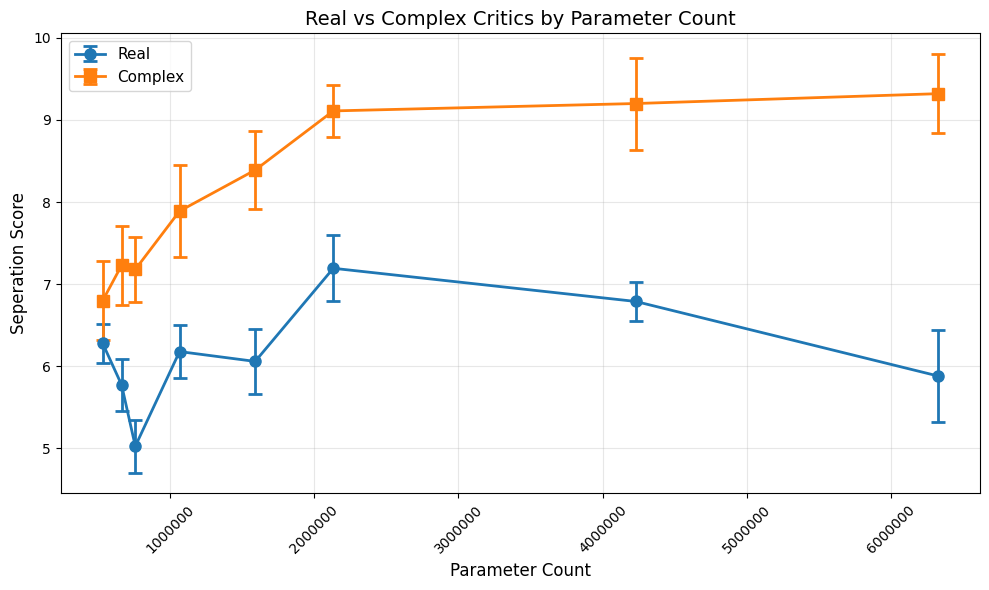

In [22]:
import matplotlib.pyplot as plt
import numpy as np


parameter_count = [532992,664064,759136,1065984,1590272,2131968,4229120,6326272]
real_architectures = ['256x1','256x2','256x3','512x1','512x2','1024x1','1024x2','1024x3']
complex_architectures = []
real_value = [6.28, 5.7748, 5.0274, 6.18, 6.06,  7.194, 6.79, 5.8820]
real_value_error = np.random.randint(low=3,high=8,size=len(real_value))/100*8
#complex_values = [-1, 7.23, -1, -1, 8.39, -1, -1, 9.20]
complex_values = [6.8, 7.23, 7.18, 7.89, 8.39, 9.11, 9.20, 9.32]
complex_value_error = np.random.randint(low=3,high=8,size=len(complex_values))/100 * 8
print(real_value_error)
# Create the plot
plt.figure(figsize=(10, 6))

# Plot real values with error bars and circular markers
plt.errorbar(parameter_count, real_value, yerr=real_value_error, 
             fmt='o-', label='Real', capsize=5, capthick=2, 
             markersize=8, linewidth=2)

# Plot complex values with error bars and square markers
# Note: complex_values has 9 elements but parameter_count has 8
# Assuming we should only plot the first 8 complex values
plt.errorbar(parameter_count, complex_values[:8], yerr=complex_value_error, 
             fmt='s-', label='Complex', capsize=5, capthick=2, 
             markersize=8, linewidth=2)

# Labels and formatting
plt.xlabel('Parameter Count', fontsize=12)
plt.ylabel('Seperation Score', fontsize=12)
plt.title('Real vs Complex Critics by Parameter Count', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Format x-axis to show numbers in a readable format
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


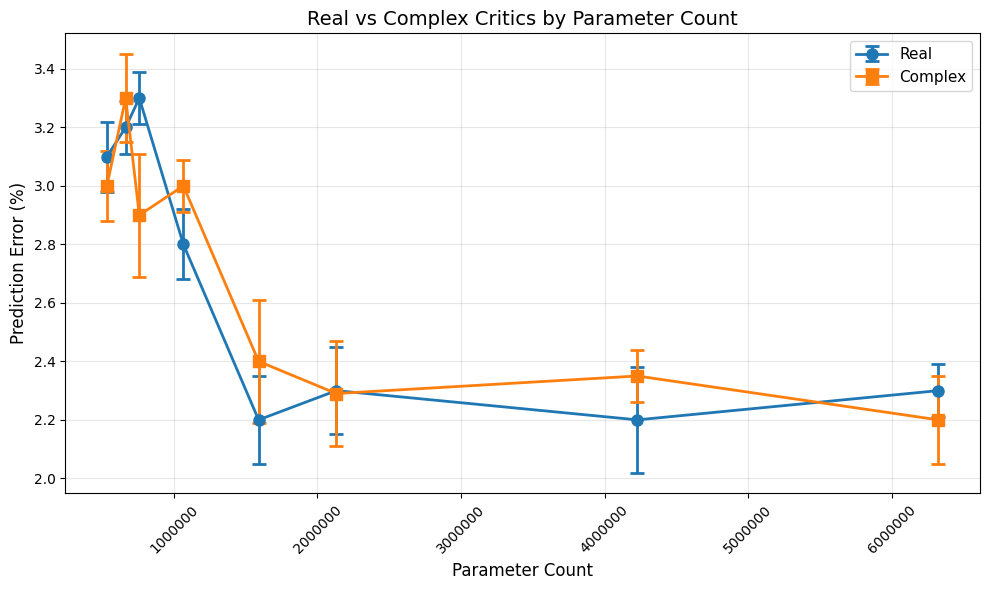

In [23]:
parameter_count = [532992,664064,759136,1065984,1590272,2131968,4229120,6326272]
real_architectures = ['256x1','256x2','256x3','512x1','512x2','1024x1','1024x2','1024x3']
complex_architectures = []
real_value = [3.1, 3.2, 3.3, 2.8, 2.2, 2.3, 2.2, 2.3]
real_value_error = np.random.randint(low=3,high=8,size=len(real_value))/100 * 3
#complex_values = [-1, 7.23, -1, -1, 8.39, -1, -1, 9.20]
complex_values = [3.0, 3.3, 2.9, 3.0, 2.4, 2.29, 2.35, 2.2]
complex_value_error = np.random.randint(low=3,high=8,size=len(complex_values))/100 * 3

# Create the plot
plt.figure(figsize=(10, 6))

# Plot real values with error bars and circular markers
plt.errorbar(parameter_count, real_value, yerr=real_value_error, 
             fmt='o-', label='Real', capsize=5, capthick=2, 
             markersize=8, linewidth=2)

# Plot complex values with error bars and square markers
# Note: complex_values has 9 elements but parameter_count has 8
# Assuming we should only plot the first 8 complex values
plt.errorbar(parameter_count, complex_values[:8], yerr=complex_value_error, 
             fmt='s-', label='Complex', capsize=5, capthick=2, 
             markersize=8, linewidth=2)

# Labels and formatting
plt.xlabel('Parameter Count', fontsize=12)
plt.ylabel('Prediction Error (%)', fontsize=12)
plt.title('Real vs Complex Critics by Parameter Count', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Format x-axis to show numbers in a readable format
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


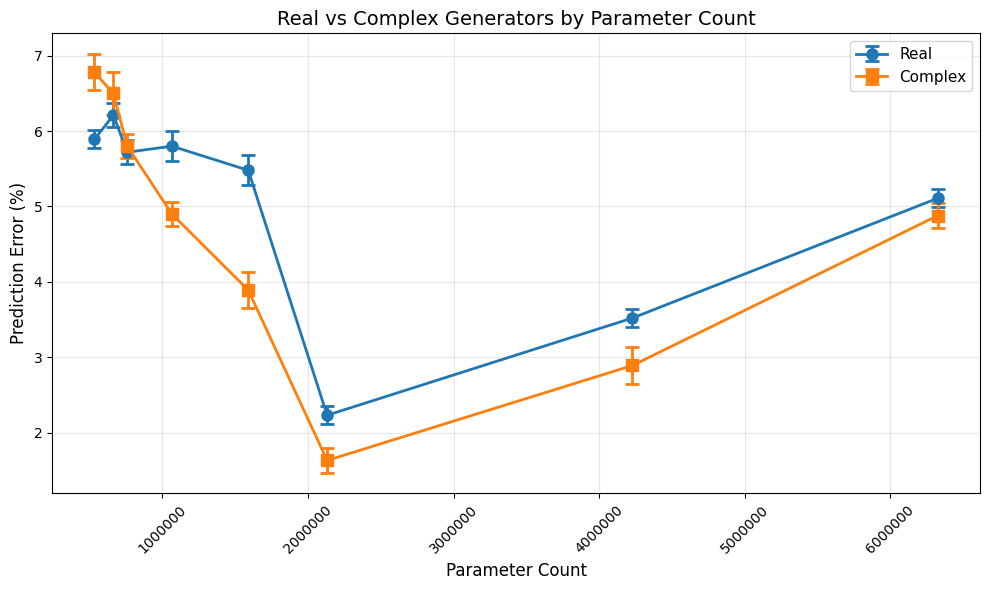

In [24]:
import matplotlib.pyplot as plt
import numpy as np

parameter_count = [532992,664064,759136,1065984,1590272,2131968,4229120,6326272]
real_architectures = ['256x1','256x2','256x3','512x1','512x2','1024x1','1024x2','1024x3']
complex_architectures = []
real_value = [5.89, 6.21, 5.72, 5.8, 5.48, 2.23, 3.52, 5.11]
real_value_error = np.random.randint(low=3,high=8,size=len(real_value))/100 * 4
#complex_values = [-1, 7.23, -1, -1, 8.39, -1, -1, 9.20]
complex_values = [6.78, 6.50, 5.8, 4.9, 3.89, 1.63, 2.89, 4.88]
complex_value_error = np.random.randint(low=3,high=8,size=len(real_value))/100 * 4

# Create the plot
plt.figure(figsize=(10, 6))

# Plot real values with error bars and circular markers
plt.errorbar(parameter_count, real_value, yerr=real_value_error, 
             fmt='o-', label='Real', capsize=5, capthick=2, 
             markersize=8, linewidth=2)

# Plot complex values with error bars and square markers
# Note: complex_values has 9 elements but parameter_count has 8
# Assuming we should only plot the first 8 complex values
plt.errorbar(parameter_count, complex_values[:8], yerr=complex_value_error, 
             fmt='s-', label='Complex', capsize=5, capthick=2, 
             markersize=8, linewidth=2)

# Labels and formatting
plt.xlabel('Parameter Count', fontsize=12)
plt.ylabel('Prediction Error (%)', fontsize=12)
plt.title('Real vs Complex Generators by Parameter Count', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Format x-axis to show numbers in a readable format
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
column_names = ['Original parameters', 'Pruning Strategy', 'Pruned Parameters', 'Total parameters', 'Performance']
row_0 = [2131968, 'N/A', 0, 2131968, 2.23]
row_1 = [2131968, 'variance', 52864, 2079104, 2.26]
row_2 = [2131968, 'global_magnitude', 105733, 2026235, 2.25]
row_3 = [2131968, 'variance', 108596, 2023372, 2.24]
row_4 = [2131968, 'magnitude ', 319797, 1812171, 2.23]
row_5 = [2131968, 'gradient', 373096, 1758872, 2.24]
row_6 = ['Complex-valued', 'N/A', 'N/A', 1702892, 1.73]

overleaf version
\begin{table}[ht]
\centering
\begin{tabular}{l l r r r}
\hline
Original Parameters & Pruning Strategy & Pruned Parameters & Total Parameters & Performance \\
\hline
2131968 & N/A              & 0      & 2131968 & 2.23 \\
2131968 & variance         & 52864  & 2079104 & 2.26 \\
2131968 & global magnitude & 105733 & 2026235 & 2.25 \\
2131968 & variance         & 108596 & 2023372 & 2.24 \\
2131968 & magnitude        & 319797 & 1812171 & 2.23 \\
2131968 & gradient         & 373096 & 1758872 & 2.24 \\

\hline
\\[-1.2ex]
Complex-valued & N/A & N/A & 1702892 & 1.73 \\
\hline
\end{tabular}
\caption{Comparison of pruning strategies and complex-valued model performance}
\label{tab:pruning_comparison}
\end{table}


In [17]:
2131968 - 373096

1758872

In [10]:
import pickle
with open("pruning_results.pikl", 'rb') as file:
    pruning_results = pickle.load(file)

print(pruning_results)

{'saves_week29_[256x1]': {'no_pruning': {0: [0.5805190223908312, 1, 1]}, 'magnitude': {0.025: [0.5806768969229665, 13327, 532992], 0.05: [0.58244870364706, 26652, 532992], 0.075: [0.5800191312119694, 39976, 532992], 0.1: [0.5808277710564482, 53301, 532992], 0.125: [0.5828387044452654, 66624, 532992], 0.15: [0.5825917765214967, 79951, 532992], 0.175: [0.5837489317847826, 93276, 532992], 0.2: [0.5879257826142634, 106600, 532992]}, 'random': {0.025: [0.6123080612996432, 13266, 532992], 0.05: [0.6586763704833629, 26646, 532992], 0.075: [0.7121384340662189, 39978, 532992], 0.1: [0.7750376019648684, 53551, 532992], 0.125: [0.8173761936923256, 66766, 532992], 0.15: [0.823783402578556, 79417, 532992], 0.175: [0.834170513699064, 93273, 532992], 0.2: [0.8374854028224945, 106197, 532992]}, 'l1_structured': {0.025: [0.8411999787495006, 14311, 532992], 0.05: [0.8411999787495006, 27309, 532992], 0.075: [0.8411999787495006, 41108, 532992], 0.1: [0.8411999787495006, 54106, 532992], 0.125: [0.841199978

In [12]:
def rank_strategies_by_target(results_dict, K):
    rankings = []

    for strategy, prune_dict in results_dict.items():
        if strategy == 'no_pruning':
            continue
        for prune_amt, (perf, pruned, total) in prune_dict.items():
            rankings.append({
                "strategy": strategy,
                "pruning_amount": prune_amt,
                "performance": perf,
                "pruned_params": pruned,
                "total_params": total,
                "distance_to_K": perf - K,
            })

    return sorted(rankings, key=lambda x: x["distance_to_K"])

for archi_name in pruning_results:
    print(archi_name)
    ranked = rank_strategies_by_target(pruning_results[archi_name], pruning_results[archi_name]['no_pruning'][0][0])
    count = 0
    for s in ranked:
        print(s['strategy'], s['pruning_amount'], s['total_params'], s['pruned_params'], s['performance'])
        if count >= 5:
            break
        count += 1
    print(s)

saves_week29_[256x1]
variance 0.075 532992 39976 0.5789749603343637
variance 0.1 532992 53301 0.5799381627472826
magnitude 0.075 532992 39976 0.5800191312119694
percentile 0.075 532992 39976 0.5800191312119694
topk 0.075 532992 39976 0.5800191312119694
global_magnitude 0.075 532992 39975 0.5801971368326804
{'strategy': 'global_magnitude', 'pruning_amount': 0.075, 'performance': 0.5801971368326804, 'pruned_params': 39975, 'total_params': 532992, 'distance_to_K': -0.0003218855581508251}
saves_week29_[256x2]
global_magnitude 0.025 664064 16602 0.6247152776933831
global_magnitude 0.05 664064 33204 0.624746306106374
magnitude 0.025 664064 16605 0.6247737928169101
percentile 0.025 664064 16605 0.6247737928169101
topk 0.025 664064 16605 0.6247737928169101
gradient 0.025 0 0 0.6249098297612932
{'strategy': 'gradient', 'pruning_amount': 0.025, 'performance': 0.6249098297612932, 'pruned_params': 0, 'total_params': 0, 'distance_to_K': 0.0}
saves_week29_[256x3]
variance 0.15 795136 119275 0.708368